# Phishing Website Detection
**Yousiff Rashwan** (yar24) — Rutgers, Spring 2026

This notebook looks at whether common URL and website features can separate phishing pages from legitimate ones.  
I start with a straightforward baseline, compare a few models, and then check whether the same setup still holds up on a second phishing dataset.

My goal here is not just to get a high score, but to understand which model choices transfer reasonably well and which results might be dataset-specific.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100


## Load data

I started with the PhiUSIIL dataset because it already comes with a rich set of phishing-related features.  
Before modeling anything, I wanted to confirm the label column was clean and get a quick sense of the class balance.


In [2]:
df = pd.read_csv('PhiUSIIL_Phishing_URL_Dataset.csv')
print(f'{df.shape[0]:,} rows, {df.shape[1]} columns')
df.head()


235,795 rows, 56 columns


,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


In [3]:
df.info(verbose=True, show_counts=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 56 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   FILENAME                    235795 non-null  object 
 1   URL                         235795 non-null  object 
 2   URLLength                   235795 non-null  int64  
 3   Domain                      235795 non-null  object 
 4   DomainLength                235795 non-null  int64  
 5   IsDomainIP                  235795 non-null  int64  
 6   TLD                         235795 non-null  object 
 7   URLSimilarityIndex          235795 non-null  float64
 8   CharContinuationRate        235795 non-null  float64
 9   TLDLegitimateProb           235795 non-null  float64
 10  URLCharProb                 235795 non-null  float64
 11  TLDLength                   235795 non-null  int64  
 12  NoOfSubDomain               235795 non-null  int64  
 13  HasObfuscation

In [4]:
target = 'label'
df[target] = pd.to_numeric(df[target], errors='coerce').astype(int)
print(df[target].value_counts())
print()
print(df[target].value_counts(normalize=True).round(4))


label
1    134850
0    100945
Name: count, dtype: int64

label
1    0.5719
0    0.4281
Name: proportion, dtype: float64


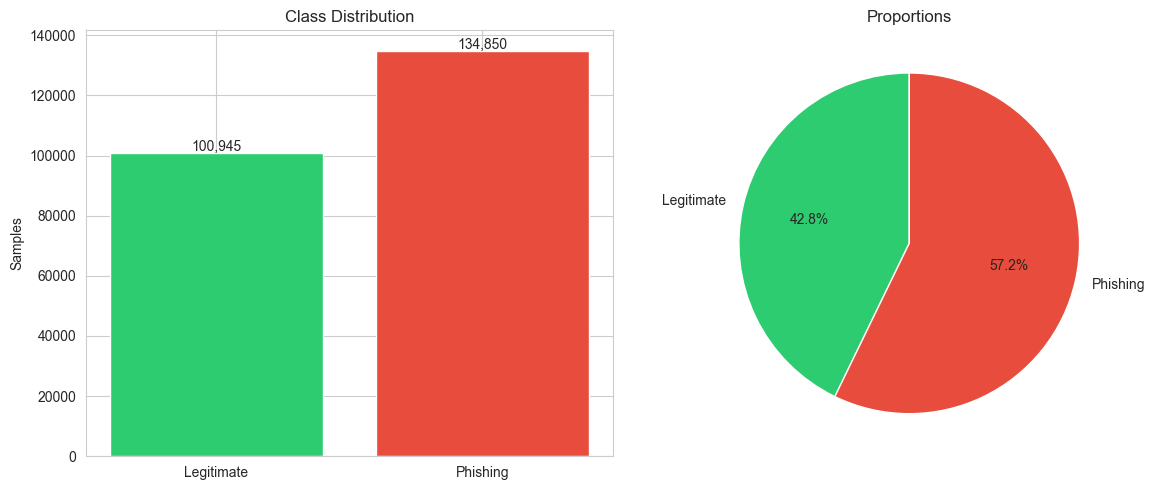

Minority/majority ratio: 0.749


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

counts = df[target].value_counts().sort_index()

ax1.bar(['Legitimate', 'Phishing'], counts.values, color=['#2ecc71', '#e74c3c'])
ax1.set_title('Class Distribution')
ax1.set_ylabel('Samples')
for i, v in enumerate(counts.values):
    ax1.text(i, v + 500, f'{v:,}', ha='center')

ax2.pie(counts.values, labels=['Legitimate', 'Phishing'], autopct='%1.1f%%',
        colors=['#2ecc71', '#e74c3c'], startangle=90)
ax2.set_title('Proportions')

plt.tight_layout()
plt.savefig('fig_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Minority/majority ratio: {counts.min() / counts.max():.3f}')


## Cleaning

Most of the cleaning here is basic sanity checking.  
I mainly wanted to remove duplicates, check for missing values, and drop text-heavy columns that would not fit the numeric modeling setup used in the rest of the notebook.


In [6]:
missing = df.isnull().sum()
missingAny = missing[missing > 0]
if missingAny.empty:
    print('No missing values.')
else:
    print(missingAny)
    if (missingAny / len(df)).max() < 0.05:
        df.dropna(inplace=True)


No missing values.


In [7]:
print(f'Duplicates: {df.duplicated().sum()}')
df.drop_duplicates(inplace=True)


Duplicates: 0


In [8]:
allCols = [c for c in df.columns if c != target]
numCols = df[allCols].select_dtypes(include=[np.number]).columns.tolist()
txtCols = df[allCols].select_dtypes(exclude=[np.number]).columns.tolist()
print(f'Numeric: {len(numCols)}, Non-numeric: {len(txtCols)}')
if txtCols:
    for c in txtCols:
        print(f'  {c}: {df[c].nunique()} unique')


Numeric: 50, Non-numeric: 5
  FILENAME: 235795 unique
  URL: 235370 unique
  Domain: 220086 unique
  TLD: 695 unique
  Title: 197874 unique


In [9]:
toDrop = [c for c in txtCols if df[c].nunique() > 100]
if toDrop:
    print(f'Dropping: {toDrop}')
    df.drop(columns=toDrop, inplace=True)

allCols = [c for c in df.columns if c != target]
numCols = df[allCols].select_dtypes(include=[np.number]).columns.tolist()
txtCols = df[allCols].select_dtypes(exclude=[np.number]).columns.tolist()

if txtCols:
    df = pd.get_dummies(df, columns=txtCols, drop_first=True)
    allCols = [c for c in df.columns if c != target]

print(f'{len(allCols)} features, {df.shape[0]:,} rows')


Dropping: ['FILENAME', 'URL', 'Domain', 'TLD', 'Title']
50 features, 235,795 rows


In [10]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
URLLength,235795.0,34.573095,41.314153,13.000000,23.000000,27.000000,34.000000,6.097000e+03
DomainLength,235795.0,21.470396,9.150793,4.000000,16.000000,20.000000,24.000000,1.100000e+02
IsDomainIP,235795.0,0.002706,0.051946,0.000000,0.000000,0.000000,0.000000,1.000000e+00
URLSimilarityIndex,235795.0,78.430778,28.976055,0.155574,57.024793,100.000000,100.000000,1.000000e+02
CharContinuationRate,235795.0,0.845508,0.216632,0.000000,0.680000,1.000000,1.000000,1.000000e+00
TLDLegitimateProb,235795.0,0.260423,0.251628,0.000000,0.005977,0.079963,0.522907,5.229071e-01
URLCharProb,235795.0,0.055747,0.010587,0.001083,0.050747,0.057970,0.062875,9.082366e-02
TLDLength,235795.0,2.764456,0.599739,2.000000,2.000000,3.000000,3.000000,1.300000e+01
NoOfSubDomain,235795.0,1.164758,0.600969,0.000000,1.000000,1.000000,1.000000,1.000000e+01
HasObfuscation,235795.0,0.002057,0.045306,0.000000,0.000000,0.000000,0.000000,1.000000e+00


## EDA

I am not trying to do exhaustive EDA here.  
This section is mainly a quick pass to see which URL and host-related features seem to separate phishing from legitimate examples and whether any columns look odd before training.


In [11]:
kw = ['url_length', 'URLLength', 'NumDots', 'NumDash', 'SubdomainLevel',
      'PathLevel', 'domain', 'IpAddress', 'HostnameLength', 'Sensitive']

edaCols = [c for c in numCols if any(k.lower() in c.lower() for k in kw)]
if len(edaCols) < 4:
    edaCols = numCols[:6]
else:
    edaCols = edaCols[:6]
print(edaCols)


['URLLength', 'DomainLength', 'IsDomainIP', 'NoOfSubDomain', 'DomainTitleMatchScore']


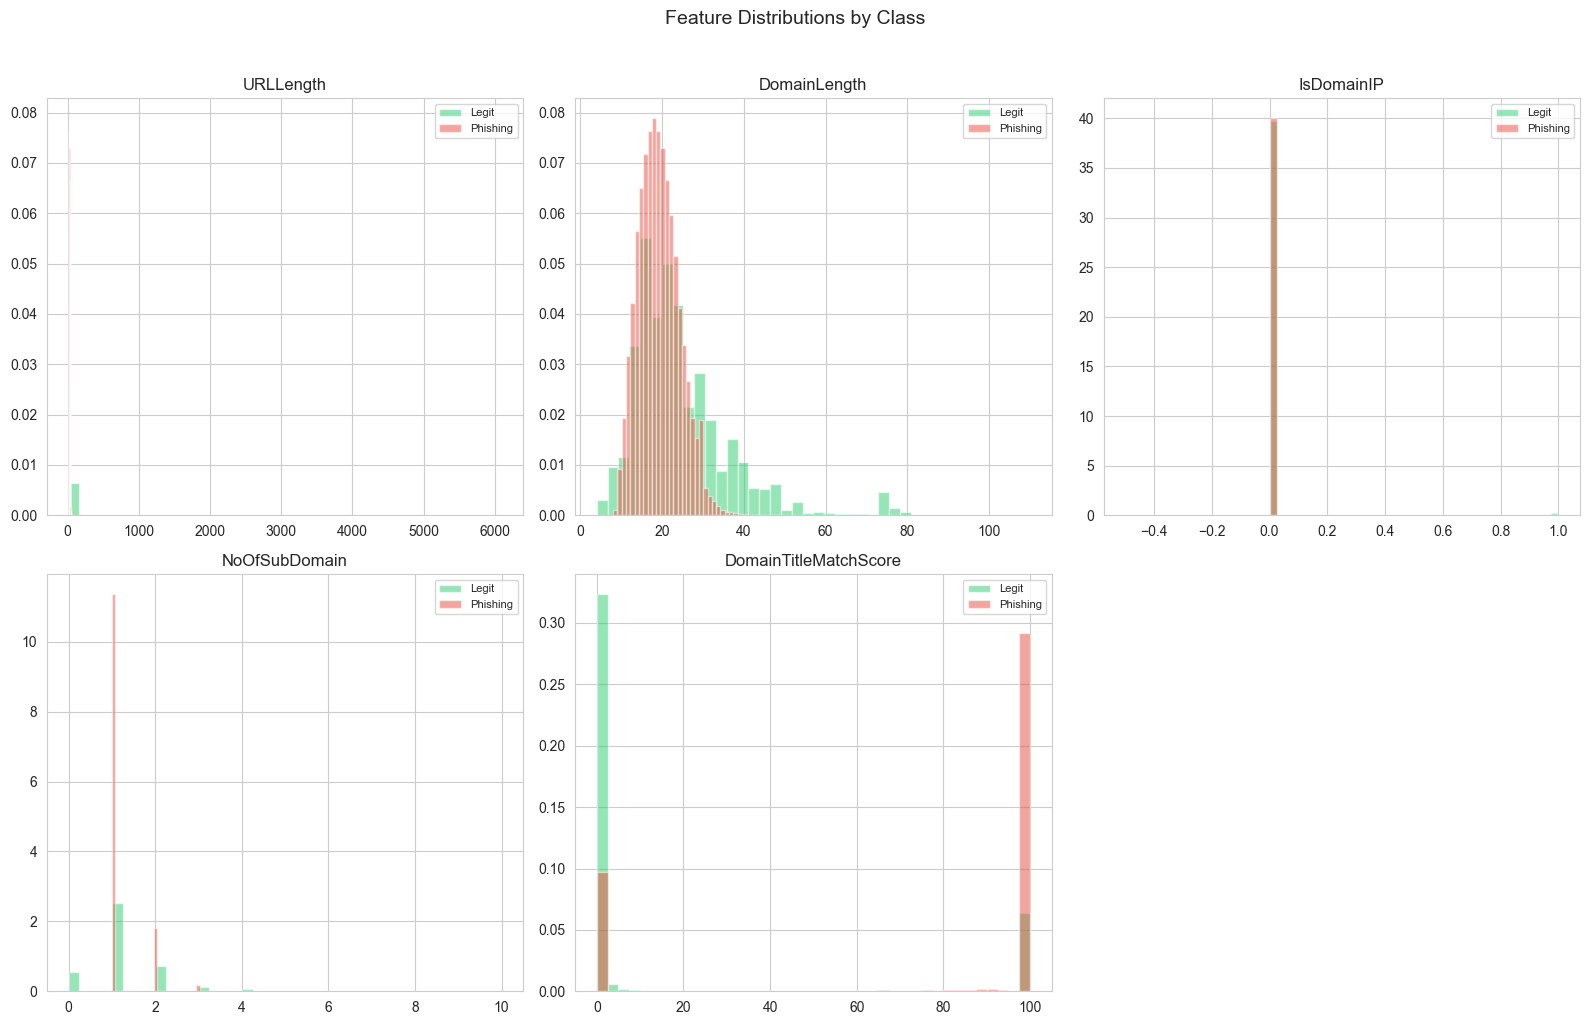

In [12]:
n = len(edaCols)
fig, axes = plt.subplots(2, (n+1)//2, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(edaCols):
    for lv, color, name in zip([0,1], ['#2ecc71','#e74c3c'], ['Legit','Phishing']):
        axes[i].hist(df[df[target]==lv][col], bins=40, alpha=0.5, color=color, label=name, density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Feature Distributions by Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


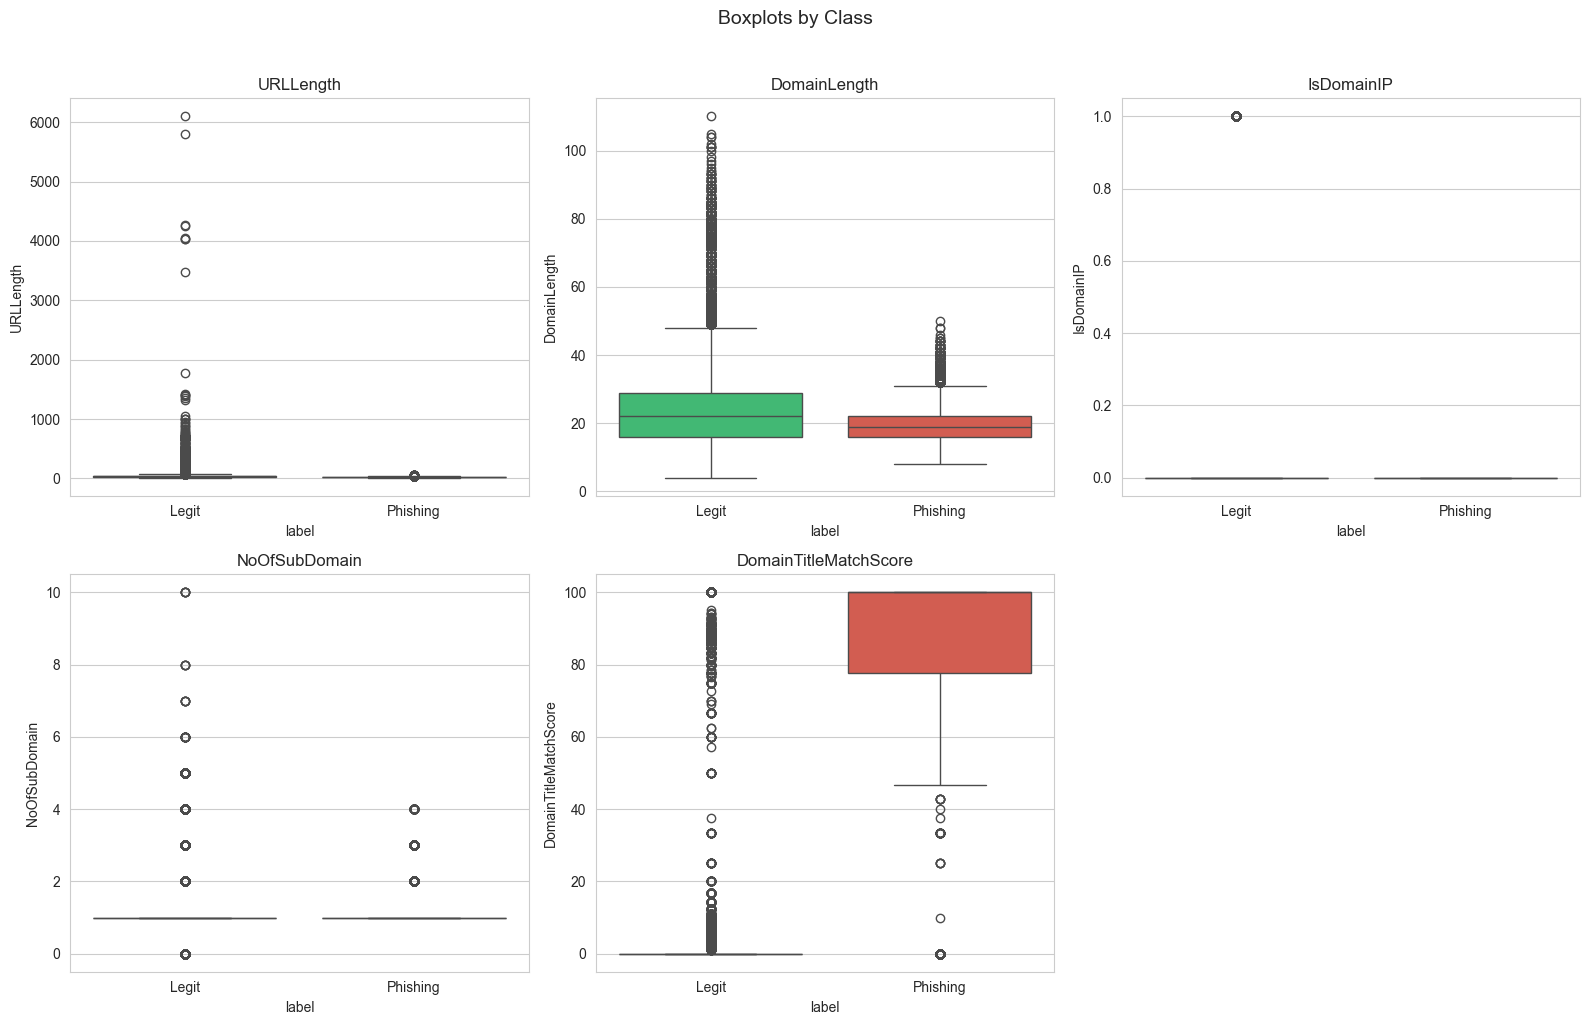

In [13]:
fig, axes = plt.subplots(2, (n+1)//2, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(edaCols):
    sns.boxplot(data=df, x=target, y=col, ax=axes[i], palette=['#2ecc71','#e74c3c'])
    axes[i].set_xticklabels(['Legit','Phishing'])
    axes[i].set_title(col)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Boxplots by Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


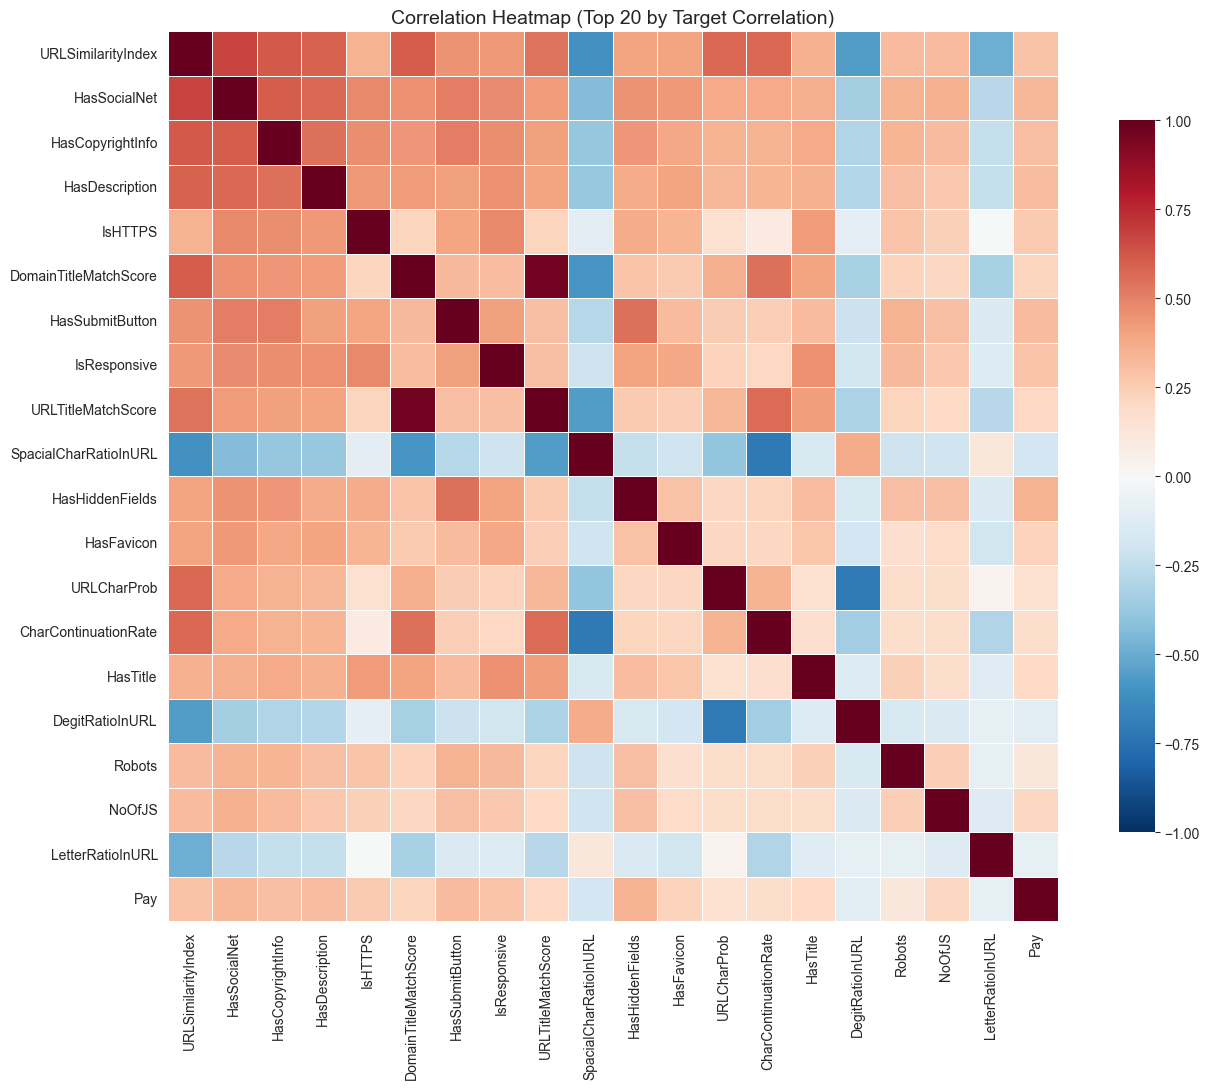

Highly correlated pairs:
  URLTitleMatchScore <-> DomainTitleMatchScore: 0.961


In [14]:
if len(numCols) > 20:
    corrTarget = df[numCols].corrwith(df[target]).abs().sort_values(ascending=False)
    topCols = corrTarget.head(20).index.tolist()
    corrMat = df[topCols].corr()
else:
    corrMat = df[numCols].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corrMat, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap (Top 20 by Target Correlation)', fontsize=14)
plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

upper = corrMat.where(np.triu(np.ones(corrMat.shape), k=1).astype(bool))
highPairs = [(c1, c2, upper.loc[c2,c1]) for c1 in upper.columns for c2 in upper.index if abs(upper.loc[c2,c1]) > 0.9]
if highPairs:
    print('Highly correlated pairs:')
    for a, b, r in sorted(highPairs, key=lambda x: -abs(x[2])):
        print(f'  {a} <-> {b}: {r:.3f}')
else:
    print('No pairs above |r|=0.9')


## Train / test split

I kept a simple stratified 80/20 split so the class ratio stays consistent between training and testing.  
I also only turn on class weighting when the training split looks noticeably imbalanced instead of forcing it by default.


In [15]:
feats = df.drop(columns=[target])
labels = df[target]

featsTrain, featsTest, labelsTrain, labelsTest = train_test_split(
    feats, labels, test_size=0.20, stratify=labels, random_state=42
)

print(f'Train: {featsTrain.shape[0]:,}  Test: {featsTest.shape[0]:,}')
print(labelsTrain.value_counts(normalize=True).round(4))


Train: 188,636  Test: 47,159
label
1    0.5719
0    0.4281
Name: proportion, dtype: float64


In [16]:
minorityMajorityRatio = labelsTrain.value_counts().min() / labelsTrain.value_counts().max()

# I only force class balancing when the split looks noticeably uneven.
classWt = 'balanced' if minorityMajorityRatio < 0.6 else None
print(f'class weight: {classWt or "none"}')


class weight: none


## Models

I picked three models for different reasons:

- Logistic Regression as a clean baseline
- Decision Tree to see whether a simple rule-based model can capture the patterns
- Random Forest as the stronger nonlinear model

I only scale the Logistic Regression pipeline because the tree-based models do not need feature scaling.


In [17]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [18]:
# Logistic Regression is my baseline, and this is the one model here that benefits from scaling.
lrPipe = Pipeline([
    ('scale', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, class_weight=classWt, random_state=42))
])

lrCV = cross_val_score(lrPipe, featsTrain, labelsTrain, cv=kfold, scoring='f1')
print(f'LR CV F1: {lrCV.mean():.4f} +/- {lrCV.std():.4f}')

lrPipe.fit(featsTrain, labelsTrain)
lrPred = lrPipe.predict(featsTest)
lrProb = lrPipe.predict_proba(featsTest)[:,1]
print(classification_report(labelsTest, lrPred, target_names=['Legit','Phishing']))


LR CV F1: 0.9999 +/- 0.0001
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     20189
    Phishing       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



In [19]:
# Decision Trees do not need scaling, so I keep this pipeline simple.
treePipe = Pipeline([
    ('model', DecisionTreeClassifier(max_depth=10, class_weight=classWt, random_state=42))
])

treeCV = cross_val_score(treePipe, featsTrain, labelsTrain, cv=kfold, scoring='f1')
print(f'DT CV F1: {treeCV.mean():.4f} +/- {treeCV.std():.4f}')

treePipe.fit(featsTrain, labelsTrain)
treePred = treePipe.predict(featsTest)
treeProb = treePipe.predict_proba(featsTest)[:,1]
print(classification_report(labelsTest, treePred, target_names=['Legit','Phishing']))


DT CV F1: 1.0000 +/- 0.0000
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     20189
    Phishing       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



In [20]:
# Random Forest also does not need scaling. I use it as the strongest non-linear model in this comparison.
forestPipe = Pipeline([
    ('model', RandomForestClassifier(n_estimators=200, class_weight=classWt,
                                     random_state=42, n_jobs=-1))
])

forestCV = cross_val_score(forestPipe, featsTrain, labelsTrain, cv=kfold, scoring='f1')
print(f'RF CV F1: {forestCV.mean():.4f} +/- {forestCV.std():.4f}')

forestPipe.fit(featsTrain, labelsTrain)
forestPred = forestPipe.predict(featsTest)
forestProb = forestPipe.predict_proba(featsTest)[:,1]
print(classification_report(labelsTest, forestPred, target_names=['Legit','Phishing']))


RF CV F1: 1.0000 +/- 0.0000
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     20189
    Phishing       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



## Model comparison

At this stage I care more about **F1** and **AUC** than raw accuracy.  
For phishing detection, accuracy alone can look better than the model really is, especially if one class is easier to predict than the other.


In [21]:
results = pd.DataFrame([
    {'Model': 'Logistic Regression',
     'Accuracy': accuracy_score(labelsTest, lrPred),
     'Precision': precision_score(labelsTest, lrPred),
     'Recall': recall_score(labelsTest, lrPred),
     'F1': f1_score(labelsTest, lrPred),
     'AUC': roc_auc_score(labelsTest, lrProb)},
    {'Model': 'Decision Tree',
     'Accuracy': accuracy_score(labelsTest, treePred),
     'Precision': precision_score(labelsTest, treePred),
     'Recall': recall_score(labelsTest, treePred),
     'F1': f1_score(labelsTest, treePred),
     'AUC': roc_auc_score(labelsTest, treeProb)},
    {'Model': 'Random Forest',
     'Accuracy': accuracy_score(labelsTest, forestPred),
     'Precision': precision_score(labelsTest, forestPred),
     'Recall': recall_score(labelsTest, forestPred),
     'F1': f1_score(labelsTest, forestPred),
     'AUC': roc_auc_score(labelsTest, forestProb)},
])
results.set_index('Model').style.format('{:.4f}').highlight_max(axis=0, color='#d4edda')


,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
Logistic Regression,0.9999,0.9998,1.0000,0.9999,1.0000
Decision Tree,1.0000,1.0000,1.0000,1.0000,1.0000
Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000


In [22]:
print(pd.DataFrame({
    'Model': ['LR','DT','RF'],
    'CV F1 Mean': [lrCV.mean(), treeCV.mean(), forestCV.mean()],
    'CV F1 Std': [lrCV.std(), treeCV.std(), forestCV.std()],
}).to_string(index=False))


Model  CV F1 Mean  CV F1 Std
   LR    0.999903   0.000061
   DT    1.000000   0.000000
   RF    0.999995   0.000009


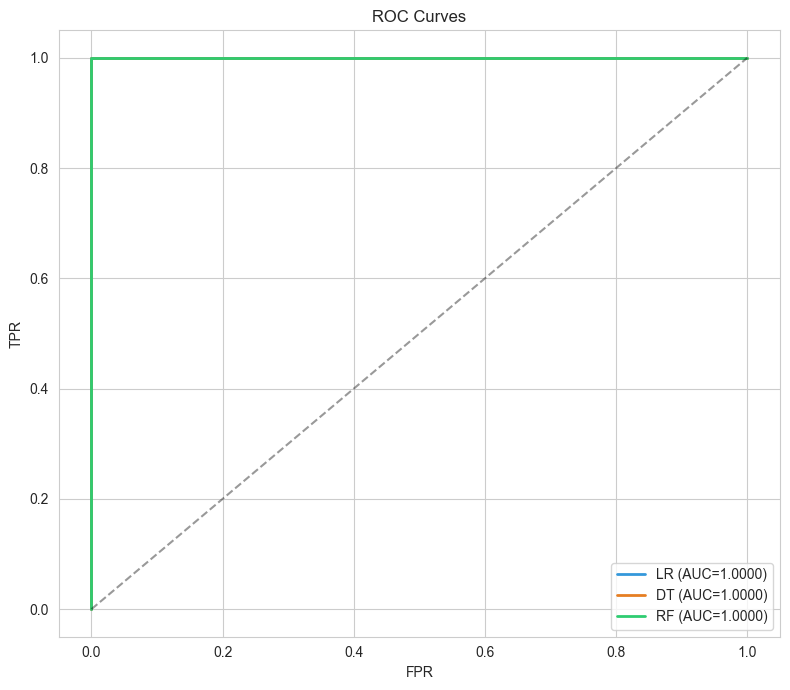

In [23]:
fig, ax = plt.subplots(figsize=(8, 7))

fpr1, tpr1, _ = roc_curve(labelsTest, lrProb)
fpr2, tpr2, _ = roc_curve(labelsTest, treeProb)
fpr3, tpr3, _ = roc_curve(labelsTest, forestProb)

ax.plot(fpr1, tpr1, label=f'LR (AUC={roc_auc_score(labelsTest, lrProb):.4f})', color='#3498db', linewidth=2)
ax.plot(fpr2, tpr2, label=f'DT (AUC={roc_auc_score(labelsTest, treeProb):.4f})', color='#e67e22', linewidth=2)
ax.plot(fpr3, tpr3, label=f'RF (AUC={roc_auc_score(labelsTest, forestProb):.4f})', color='#2ecc71', linewidth=2)
ax.plot([0,1],[0,1],'k--', alpha=0.4)
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title('ROC Curves')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('fig_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()


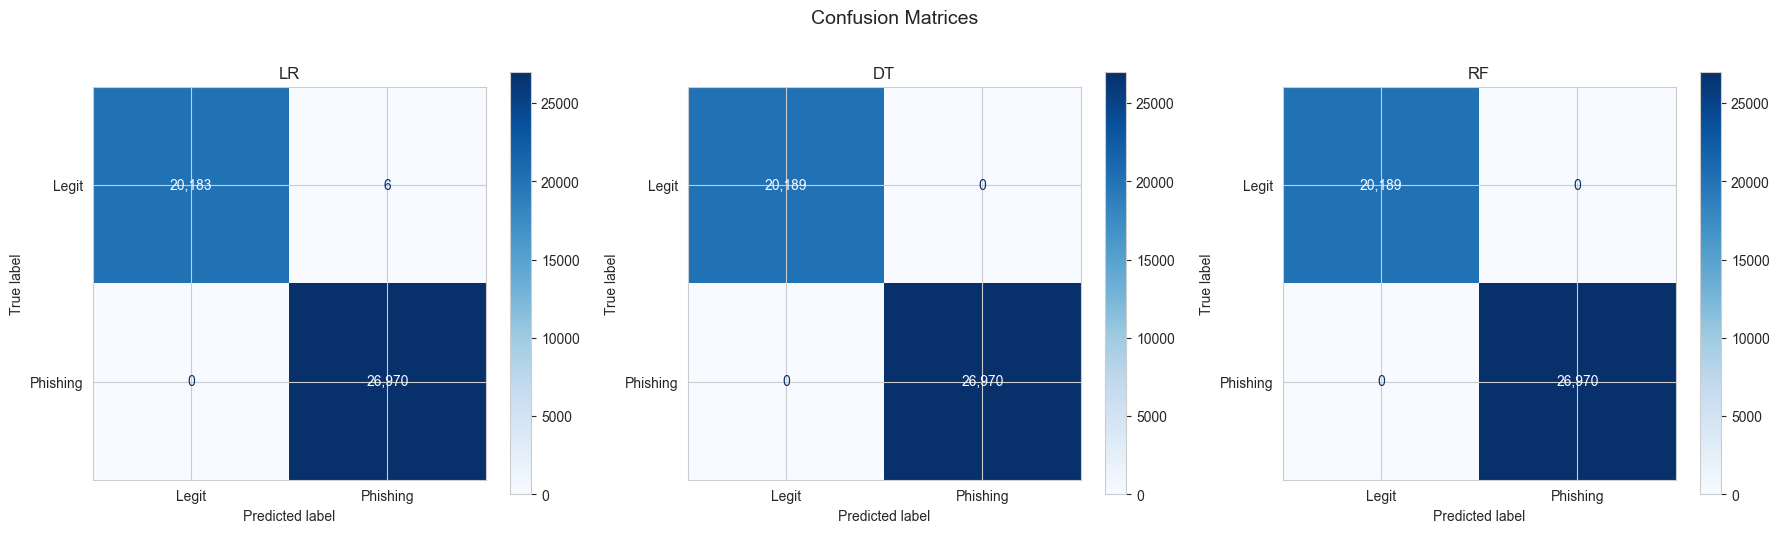

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm1 = confusion_matrix(labelsTest, lrPred)
cm2 = confusion_matrix(labelsTest, treePred)
cm3 = confusion_matrix(labelsTest, forestPred)

ConfusionMatrixDisplay(cm1, display_labels=['Legit','Phishing']).plot(ax=axes[0], cmap='Blues', values_format=',d')
axes[0].set_title('LR')
ConfusionMatrixDisplay(cm2, display_labels=['Legit','Phishing']).plot(ax=axes[1], cmap='Blues', values_format=',d')
axes[1].set_title('DT')
ConfusionMatrixDisplay(cm3, display_labels=['Legit','Phishing']).plot(ax=axes[2], cmap='Blues', values_format=',d')
axes[2].set_title('RF')

plt.suptitle('Confusion Matrices', fontsize=14, y=1.03)
plt.tight_layout()
plt.savefig('fig_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


## Feature importance

This part helps me sanity-check what the models are paying attention to.  
For Logistic Regression, I look at the largest positive and negative coefficients. For Random Forest, I use feature importance to see which signals contribute the most overall.


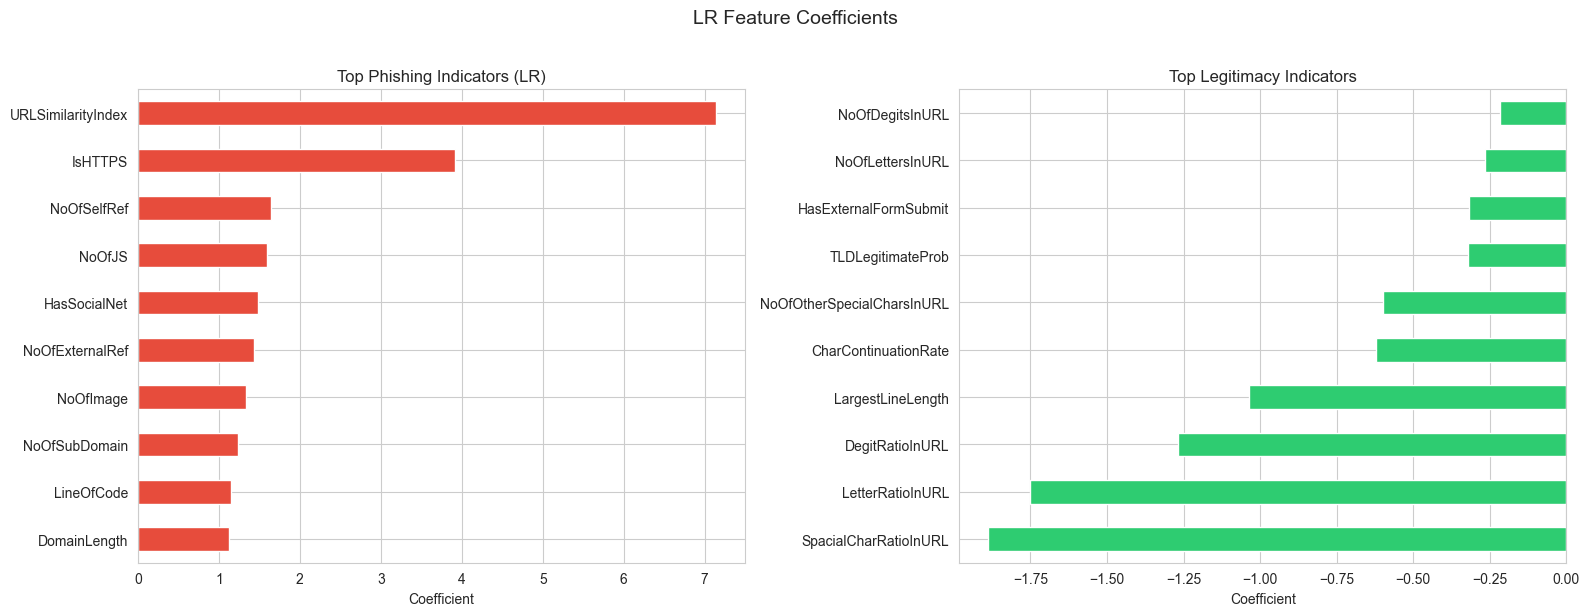

In [25]:
lrCoefs = pd.Series(lrPipe.named_steps['model'].coef_[0], index=featsTrain.columns)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

lrCoefs.nlargest(10).sort_values().plot.barh(ax=ax1, color='#e74c3c')
ax1.set_title('Top Phishing Indicators (LR)')
ax1.set_xlabel('Coefficient')

lrCoefs.nsmallest(10).sort_values().plot.barh(ax=ax2, color='#2ecc71')
ax2.set_title('Top Legitimacy Indicators')
ax2.set_xlabel('Coefficient')

plt.suptitle('LR Feature Coefficients', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()


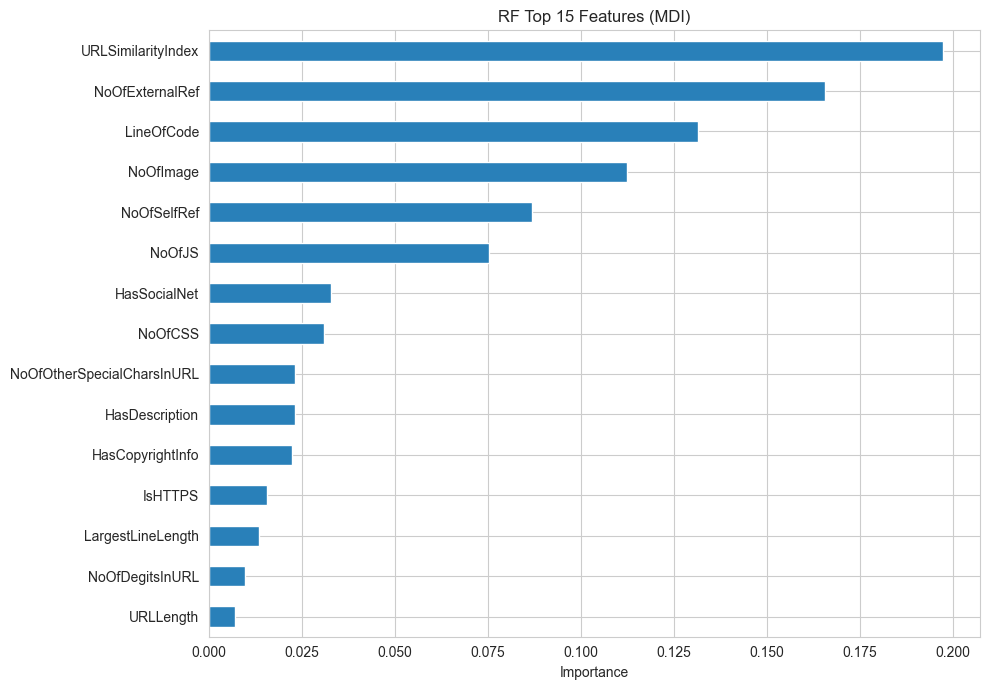

1. URLSimilarityIndex             0.1974
2. NoOfExternalRef                0.1656
3. LineOfCode                     0.1314
4. NoOfImage                      0.1125
5. NoOfSelfRef                    0.0869
6. NoOfJS                         0.0754
7. HasSocialNet                   0.0329
8. NoOfCSS                        0.0309
9. NoOfOtherSpecialCharsInURL     0.0232
10. HasDescription                 0.0231


In [26]:
rfModel = forestPipe.named_steps['model']
rfImp = pd.Series(rfModel.feature_importances_, index=featsTrain.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
rfImp.head(15).sort_values().plot.barh(ax=ax, color='#2980b9')
ax.set_title('RF Top 15 Features (MDI)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('fig_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

for i, (feat, imp) in enumerate(rfImp.head(10).items(), 1):
    print(f'{i}. {feat:30s} {imp:.4f}')


## Hyperparameter tuning

I only tuned the Random Forest more deeply because it looked strongest in the first pass.  
I did not spend extra time tuning every model since that would add more work without changing the main comparison much.


In [27]:
# I only tune the model that already looked strongest in the earlier comparison.
tuner = RandomizedSearchCV(
    forestPipe,
    {'model__n_estimators': [100,200,300,500],
     'model__max_depth': [None,10,20,30],
     'model__min_samples_split': [2,5,10],
     'model__min_samples_leaf': [1,2,4],
     'model__max_features': ['sqrt','log2']},
    n_iter=20, cv=kfold, scoring='f1', random_state=42, n_jobs=-1, verbose=1
)
tuner.fit(featsTrain, labelsTrain)

print(f'\nBest CV F1: {tuner.best_score_:.4f}')
print(f'Params: {tuner.best_params_}')

tunedPred = tuner.predict(featsTest)
tunedProb = tuner.predict_proba(featsTest)[:,1]
print(classification_report(labelsTest, tunedPred, target_names=['Legit','Phishing']))


Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best CV F1: 1.0000
Params: {'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 30}
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     20189
    Phishing       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



## Final results

This section brings the baseline and tuned results together so I can compare performance in one place and decide whether the extra tuning effort was actually worth it.


In [28]:
allResults = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Accuracy': accuracy_score(labelsTest, lrPred),
     'Precision': precision_score(labelsTest, lrPred), 'Recall': recall_score(labelsTest, lrPred),
     'F1': f1_score(labelsTest, lrPred), 'AUC': roc_auc_score(labelsTest, lrProb)},
    {'Model': 'Decision Tree', 'Accuracy': accuracy_score(labelsTest, treePred),
     'Precision': precision_score(labelsTest, treePred), 'Recall': recall_score(labelsTest, treePred),
     'F1': f1_score(labelsTest, treePred), 'AUC': roc_auc_score(labelsTest, treeProb)},
    {'Model': 'Random Forest', 'Accuracy': accuracy_score(labelsTest, forestPred),
     'Precision': precision_score(labelsTest, forestPred), 'Recall': recall_score(labelsTest, forestPred),
     'F1': f1_score(labelsTest, forestPred), 'AUC': roc_auc_score(labelsTest, forestProb)},
    {'Model': 'Tuned RF', 'Accuracy': accuracy_score(labelsTest, tunedPred),
     'Precision': precision_score(labelsTest, tunedPred), 'Recall': recall_score(labelsTest, tunedPred),
     'F1': f1_score(labelsTest, tunedPred), 'AUC': roc_auc_score(labelsTest, tunedProb)},
])

print('='*70)
print(allResults.to_string(index=False))
print('='*70)

best = allResults.loc[allResults['Recall'].idxmax()]
print(f'\nBest recall: {best["Model"]} ({best["Recall"]:.4f})')


              Model  Accuracy  Precision  Recall       F1  AUC
Logistic Regression  0.999873   0.999778     1.0 0.999889  1.0
      Decision Tree  1.000000   1.000000     1.0 1.000000  1.0
      Random Forest  1.000000   1.000000     1.0 1.000000  1.0
           Tuned RF  1.000000   1.000000     1.0 1.000000  1.0

Best recall: Logistic Regression (1.0000)


## Cross-dataset validation

This is the part I cared about most.  
Strong scores on one dataset are useful, but I also wanted to see whether the same modeling choices still perform well on a second phishing dataset with different features and formatting.


In [29]:
arffCols = []
arffRows = []
inData = False

with open('phishing+websites/Training Dataset.arff', 'r') as f:
    for line in f:
        line = line.strip()
        if line.lower().startswith('@attribute'):
            arffCols.append(line.split()[1])
        elif line.lower().startswith('@data'):
            inData = True
        elif inData and line and not line.startswith('%'):
            arffRows.append([int(x) for x in line.split(',')])

df2 = pd.DataFrame(arffRows, columns=arffCols)
print(f'{df2.shape[0]:,} rows x {df2.shape[1]} cols')
print(df2['Result'].value_counts())


11,055 rows x 31 cols
Result
 1    6157
-1    4898
Name: count, dtype: int64


In [30]:
df2['Result'] = df2['Result'].map({-1: 1, 1: 0})

webFeats = df2.drop(columns=['Result'])
webLabels = df2['Result']

webTrain, webTest, webTrainL, webTestL = train_test_split(
    webFeats, webLabels, test_size=0.20, stratify=webLabels, random_state=42
)
print(f'Train: {webTrain.shape[0]:,} | Test: {webTest.shape[0]:,}')


Train: 8,844 | Test: 2,211


In [31]:
webCV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

webModels = {
    'Logistic Regression': Pipeline([
        ('scale', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Decision Tree': Pipeline([
        ('model', DecisionTreeClassifier(max_depth=10, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('model', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
    ]),
}

webResults = []
for name, pipe in webModels.items():
    cvF1 = cross_val_score(pipe, webTrain, webTrainL, cv=webCV, scoring='f1')
    pipe.fit(webTrain, webTrainL)
    p = pipe.predict(webTest)
    pr = pipe.predict_proba(webTest)[:,1]
    webResults.append({
        'Model': name,
        'Accuracy': accuracy_score(webTestL, p),
        'Precision': precision_score(webTestL, p),
        'Recall': recall_score(webTestL, p),
        'F1': f1_score(webTestL, p),
        'AUC': roc_auc_score(webTestL, pr),
    })
    print(f'{name}: F1={webResults[-1]["F1"]:.4f}, AUC={webResults[-1]["AUC"]:.4f}')

webResultsDf = pd.DataFrame(webResults)
print()
print(webResultsDf[['Model','Accuracy','Precision','Recall','F1','AUC']].to_string(index=False))


Logistic Regression: F1=0.9174, AUC=0.9785
Decision Tree: F1=0.9442, AUC=0.9853
Random Forest: F1=0.9738, AUC=0.9964

              Model  Accuracy  Precision   Recall       F1      AUC
Logistic Regression  0.928087   0.934392 0.901020 0.917403 0.978504
      Decision Tree  0.950701   0.947585 0.940816 0.944188 0.985257
      Random Forest  0.976934   0.980352 0.967347 0.973806 0.996373


              Model  PhiUSIIL F1  PhiUSIIL AUC  Websites F1  Websites AUC
Logistic Regression     0.999889           1.0     0.917403      0.978504
      Decision Tree     1.000000           1.0     0.944188      0.985257
      Random Forest     1.000000           1.0     0.973806      0.996373


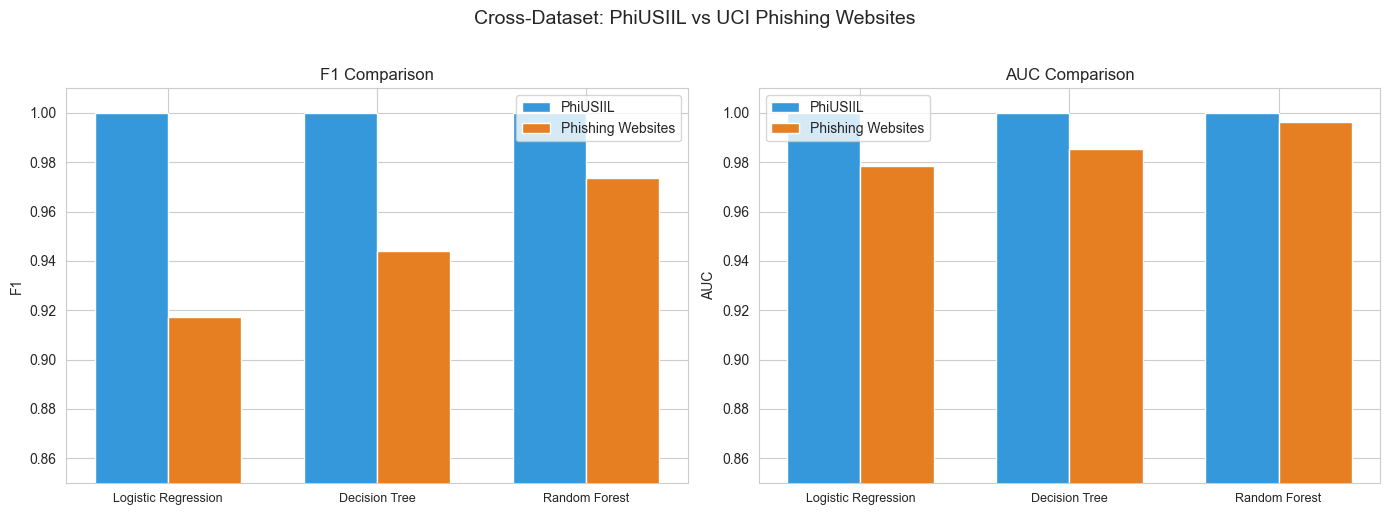

In [32]:
crossData = []
for _, r in results.iterrows():
    crossData.append({'Model': r['Model'], 'PhiUSIIL F1': r['F1'], 'PhiUSIIL AUC': r['AUC']})

for _, r in webResultsDf.iterrows():
    for item in crossData:
        if item['Model'] == r['Model']:
            item['Websites F1'] = r['F1']
            item['Websites AUC'] = r['AUC']

crossDf = pd.DataFrame(crossData)
print(crossDf.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(crossDf))
w = 0.35

ax1.bar(x-w/2, crossDf['PhiUSIIL F1'], w, label='PhiUSIIL', color='#3498db')
ax1.bar(x+w/2, crossDf['Websites F1'], w, label='Phishing Websites', color='#e67e22')
ax1.set_ylabel('F1')
ax1.set_title('F1 Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels(crossDf['Model'], fontsize=9)
ax1.legend()
ax1.set_ylim(0.85, 1.01)

ax2.bar(x-w/2, crossDf['PhiUSIIL AUC'], w, label='PhiUSIIL', color='#3498db')
ax2.bar(x+w/2, crossDf['Websites AUC'], w, label='Phishing Websites', color='#e67e22')
ax2.set_ylabel('AUC')
ax2.set_title('AUC Comparison')
ax2.set_xticks(x)
ax2.set_xticklabels(crossDf['Model'], fontsize=9)
ax2.legend()
ax2.set_ylim(0.85, 1.01)

plt.suptitle('Cross-Dataset: PhiUSIIL vs UCI Phishing Websites', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_cross_dataset.png', dpi=150, bbox_inches='tight')
plt.show()


## References

1. UCI ML Repository — PhiUSIIL Phishing URL Dataset. https://archive.ics.uci.edu/dataset/967/phiusiil+phishing+url+dataset
2. Prasad, A., & Chandra, R. (2024). PhiUSIIL: Phishing URL/Website Identification using Intrinsic and Implicit Latent features. *Computers & Security*.
3. Tang, L., & Mahmoud, Q. H. (2021). A survey of machine learning-based solutions for phishing website detection. *ML and Knowledge Extraction*, 3(3), 672-694.
4. Zieni, R., Massari, L., & Calzarossa, M. C. (2023). Phishing website detection: A systematic literature review. *J. of Computer Science*.
5. Scikit-learn Documentation. https://scikit-learn.org/stable/modules/model_evaluation.html
6. UCI ML Repository — Phishing Websites Dataset. https://archive.ics.uci.edu/dataset/327/phishing+websites
